Landmarks shape: (106, 2)


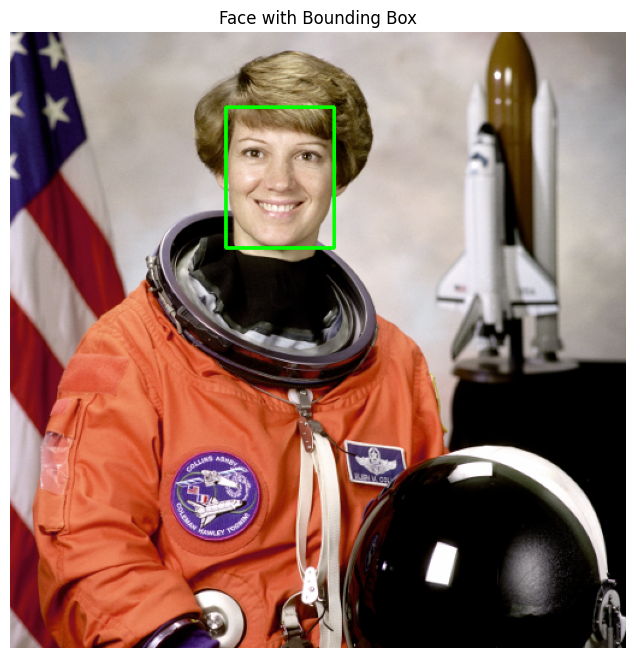

In [7]:
!pip install uniface[cpu]
import cv2
import matplotlib.pyplot as plt # Import matplotlib for displaying images
from skimage import data # Import skimage.data

from uniface.detection import RetinaFace
from uniface.landmark import Landmark106

detector = RetinaFace()
landmarker = Landmark106()

# Load a sample image from skimage.data
image_rgb = data.astronaut() # This loads an image as RGB

# Detect face
faces = detector.detect(image_rgb)

# Get detailed landmarks and draw bounding box
if faces:
    landmarks = landmarker.get_landmarks(image_rgb, faces[0].bbox)
    print(f"Landmarks shape: {landmarks.shape}")  # (106, 2)

    # Draw the bounding box on a copy of the image
    image_with_bbox = image_rgb.copy()
    x1, y1, x2, y2 = faces[0].bbox
    # OpenCV uses BGR by default for drawing, but image_rgb is RGB, so we use (0, 255, 0) for green
    cv2.rectangle(image_with_bbox, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)

    # Display the image with the bounding box
    plt.figure(figsize=(8, 8))
    plt.imshow(image_with_bbox)
    plt.title('Face with Bounding Box')
    plt.axis('off')
    plt.show()
else:
    print("No faces detected in the image.")

In [5]:
# Download a sample image for demonstration
!wget -O sample_image.jpg https://upload.wikimedia.org/wikipedia/commons/4/41/Catherine_Zeta-Jones_at_the_15th_Annual_Screen_Actors_Guild_Awards_%28cropped%29.jpg
image_path = 'sample_image.jpg'

--2026-08-25 21:57:54--  https://upload.wikimedia.org/wikipedia/commons/4/41/Catherine_Zeta-Jones_at_the_15th_Annual_Screen_Actors_Guild_Awards_%28cropped%29.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 208.80.154.240, 2620:0:861:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|208.80.154.240|:443... connected.
HTTP request sent, awaiting response... 429 Too Many Requests (015d12c)
2026-08-25 21:57:54 ERROR 429: Too Many Requests (015d12c).



# 106-Point Landmarks

In [9]:
from uniface.detection import RetinaFace
from uniface.landmark import Landmark106

detector = RetinaFace()
landmarker = Landmark106()

# Detect face
faces = detector.detect(image_rgb) # Changed 'image' to 'image_rgb'

# Get detailed landmarks
if faces:
    landmarks = landmarker.get_landmarks(image_rgb, faces[0].bbox) # Changed 'image' to 'image_rgb'
    print(f"Landmarks shape: {landmarks.shape}")  # (106, 2)

Landmarks shape: (106, 2)


# Extract Specific Features

In [11]:
# Face contour
contour = landmarks[0:33]

# Left eyebrow
left_eyebrow = landmarks[33:42]

# Right eyebrow
right_eyebrow = landmarks[42:51]

# Nose
nose = landmarks[51:63]

# Left eye
left_eye = landmarks[63:72]

# Right eye
right_eye = landmarks[76:84]

# Mouth
mouth = landmarks[87:106]

PIPNet (98 / 68 points)
PIPNet (Pixel-in-Pixel Net) is a high-accuracy facial landmark detector. UniFace ships two ONNX variants that share a ResNet-18 backbone and 256×256 input — the only difference is the number of points and the dataset they were trained on. **bold text**

# **Basic Usage**

In [13]:
from uniface.detection import RetinaFace
from uniface.landmark import PIPNet

detector = RetinaFace()
landmarker = PIPNet()  # Default: 98 points (WFLW)

faces = detector.detect(image_rgb) # Changed 'image' to 'image_rgb'
if faces:
    landmarks = landmarker.get_landmarks(image_rgb, faces[0].bbox) # Changed 'image' to 'image_rgb'
    print(f"Landmarks shape: {landmarks.shape}")  # (98, 2)

Landmarks shape: (98, 2)


# 68-Point Variant (300W+CelebA, GSSL)

In [15]:
from uniface.constants import PIPNetWeights
from uniface.landmark import PIPNet

landmarker = PIPNet(model_name=PIPNetWeights.DW300_CELEBA_68)
# Corrected to use 'image_rgb' and 'faces[0].bbox'
landmarks = landmarker.get_landmarks(image_rgb, faces[0].bbox)
print(landmarks.shape)  # (68, 2)

(68, 2)


# The 68-point 300W variant places its jaw contour more loosely than the other two, with outline points that can drift off the silhouette. If you need a tight face boundary, prefer the 98-point WFLW variant or the 106-point model.

Basic Usage
# Works with any detector — it needs a bounding box, plus the first two landmarks (the eyes) to align the crop:

In [17]:
from uniface import SCRFD, FaceMesh

detector, mesher = SCRFD(), FaceMesh()

faces = detector.detect(image_rgb) # Changed 'image' to 'image_rgb'
results = mesher.predict(image_rgb, faces)   # one batched call for all faces, changed 'image' to 'image_rgb'

if results:
    results[0].landmarks.shape   # (468, 3) — x, y in image pixels; z is relative depth
    results[0].points_2d.shape   # (468, 2) — depth dropped
    results[0].score             # face presence, [0, 1]
else:
    print("No faces detected for FaceMesh.")

# Iris landmarks
V2_478 is MediaPipe's Face Landmarker: the same 468 mesh points in the same order, plus ten iris points. Everything else — the detector, the ROI, the drawing edges — is unchanged, so switching is a one-word change.

# Following MediaPipe, the result stays a flat array and region membership lives in named constants:

In [19]:
from uniface import SCRFD, FaceMesh
from uniface.constants import FaceMeshWeights
from uniface.landmark import IRIS_LEFT, IRIS_RIGHT, NUM_MESH_LANDMARKS

mesher = FaceMesh(model_name=FaceMeshWeights.V2_478)

# Detect faces using the correct image variable
detected_faces = SCRFD().detect(image_rgb)

if detected_faces:
    # Predict mesh landmarks for the detected faces
    results = mesher.predict(image_rgb, detected_faces)

    if results:
        result = results[0] # Access the first result if available

        print(f"Landmarks shape: {result.landmarks.shape}")                  # (478, 3)
        # result.landmarks[:NUM_MESH_LANDMARKS]   # the 468 mesh points, as V1_468 returns them
        # result.landmarks[IRIS_LEFT]             # (5, 3) — center, right, top, left, bottom
        # result.landmarks[IRIS_RIGHT]            # (5, 3)

        # left_pupil = result.landmarks[IRIS_LEFT][0, :2]
    else:
        print("No FaceMesh results found for the detected faces.")
else:
    print("No faces detected by SCRFD.")


Landmarks shape: (478, 3)


Each iris is ordered center-first, so the mean distance from point 0 to the other four gives the iris radius. A human iris is close to 11.7 mm across regardless of the person, which makes that radius usable as a scale reference for real-world distance.

V2_478 runs at 256×256 against V1_468's 192×192 — 113 against 35 MMac. The wall-clock gap is narrower than that ratio since neither model saturates a modern CPU, so benchmark your own target. It is an addition, not a replacement: stay on V1_468 unless you need the irises.

Drop-in Use
# FaceMesh implements the same interface as Landmark106 and PIPNet, so it can be swapped into existing code that expects 2D points:

In [21]:
if detected_faces:
    landmarks = mesher.get_landmarks(image_rgb, detected_faces[0].bbox)   # (478, 2) for the V2_478 mesher above
    print(f"Landmarks shape from get_landmarks: {landmarks.shape}")
else:
    print("No faces detected to extract landmarks.")

Landmarks shape from get_landmarks: (478, 2)


MediaPipe Parity
# Seeding the mesh with BlazeFace — the detector MediaPipe uses internally — reproduces MediaPipe's own output:

In [23]:
from uniface import BlazeFace, FaceMesh

detector, mesher = BlazeFace(), FaceMesh()

# Detect faces using the correct image variable
detected_faces = detector.detect(image_rgb)

if detected_faces:
    results = mesher.predict(image_rgb, detected_faces)
    if results:
        # Process results here, e.g., print shape of landmarks
        print(f"FaceMesh results found with {len(results)} faces.")
        print(f"First face landmarks shape: {results[0].landmarks.shape}")
    else:
        print("No FaceMesh results found for the detected faces.")
else:
    print("No faces detected by BlazeFace.")

FaceMesh results found with 1 faces.
First face landmarks shape: (468, 3)


# Visualization

In [24]:
from uniface.draw import draw_mesh

draw_mesh(image, results[0].landmarks)                 # 'partial': contours + points
draw_mesh(image, results[0].landmarks, mode='full')    # dense 2556-edge tessellation
draw_mesh(image, results[0].landmarks, mode='points')  # points only

# 5-Point Landmarks (Detection)
# All detection models except BlazeFace provide 5-point landmarks. BlazeFace returns 6 MediaPipe keypoints instead, so its supports_alignment is False; see Detection.

In [26]:
from uniface.detection import RetinaFace

detector = RetinaFace()
faces = detector.detect(image_rgb) # Changed 'image' to 'image_rgb'

if faces:
    landmarks_5 = faces[0].landmarks
    print(f"Shape: {landmarks_5.shape}")  # (5, 2)

    left_eye = landmarks_5[0]
    right_eye = landmarks_5[1]
    nose = landmarks_5[2]
    left_mouth = landmarks_5[3]
    right_mouth = landmarks_5[4]
else:
    print("No faces detected.")

Shape: (5, 2)


**Visualization**
# Draw 106 Landmarks

In [28]:
import cv2

def draw_landmarks(image, landmarks, color=(0, 255, 0), radius=2):
    """Draw landmarks on image."""
    for x, y in landmarks.astype(int):
        cv2.circle(image, (x, y), radius, color, -1)
    return image

# Usage
# Ensure faces are detected before trying to get landmarks
if faces:
    landmarks = landmarker.get_landmarks(image_rgb, faces[0].bbox) # Corrected 'image' to 'image_rgb' and 'face.bbox' to 'faces[0].bbox'
    image_with_landmarks = draw_landmarks(image_rgb.copy(), landmarks) # Use image_rgb for drawing
    cv2.imwrite("landmarks.jpg", image_with_landmarks)
    print("Landmarks drawn and saved to landmarks.jpg")
else:
    print("No faces detected to draw landmarks on.")

Landmarks drawn and saved to landmarks.jpg


# Draw with Connections

In [29]:
def draw_landmarks_with_connections(image, landmarks):
    """Draw landmarks with facial feature connections."""
    landmarks = landmarks.astype(int)

    # Face contour (0-32)
    for i in range(32):
        cv2.line(image, tuple(landmarks[i]), tuple(landmarks[i+1]), (255, 255, 0), 1)

    # Left eyebrow (33-41)
    for i in range(33, 41):
        cv2.line(image, tuple(landmarks[i]), tuple(landmarks[i+1]), (0, 255, 0), 1)

    # Right eyebrow (42-50)
    for i in range(42, 50):
        cv2.line(image, tuple(landmarks[i]), tuple(landmarks[i+1]), (0, 255, 0), 1)

    # Nose (51-62)
    for i in range(51, 62):
        cv2.line(image, tuple(landmarks[i]), tuple(landmarks[i+1]), (0, 0, 255), 1)

    # Draw points
    for x, y in landmarks:
        cv2.circle(image, (x, y), 2, (0, 255, 255), -1)

    return image

# Use Cases
# Face Alignment

In [31]:
from uniface.face_utils import face_alignment

# Align face using 5-point landmarks
if faces:
    aligned, _ = face_alignment(image_rgb, faces[0].landmarks) # Changed 'image' to 'image_rgb'
    print("Face aligned successfully.")
    # Returns: (112x112 aligned face, inverse transform matrix)
else:
    print("No faces detected for alignment.")

Face aligned successfully.


# Eye Aspect Ratio (Blink Detection)

In [34]:
import numpy as np

def eye_aspect_ratio(eye_landmarks):
    """Calculate eye aspect ratio for blink detection."""
    # Vertical distances
    v1 = np.linalg.norm(eye_landmarks[1] - eye_landmarks[5])
    v2 = np.linalg.norm(eye_landmarks[2] - eye_landmarks[4])

    # Horizontal distance
    h = np.linalg.norm(eye_landmarks[0] - eye_landmarks[3])

    ear = (v1 + v2) / (2.0 * h)
    return ear

# Usage with 106-point landmarks
# The eye_aspect_ratio function expects 6 points. We will explicitly slice 6 points.
# Assuming landmarks[63:69] correspond to the 6 points for the left eye in the 106-point model.
left_eye_for_ear = landmarks[63:69] # Explicitly select 6 points

# Add a check to ensure we have enough points before calculating EAR
if left_eye_for_ear.shape[0] >= 6:
    ear = eye_aspect_ratio(left_eye_for_ear)

    print(f"Calculated EAR: {ear:.3f}")
    if ear < 0.2:
        print("Eye closed (blink detected)")
    else:
        print("Eye open")
else:
    print(f"Not enough points ({left_eye_for_ear.shape[0]}) available for EAR calculation. Expected at least 6.")

Not enough points (5) available for EAR calculation. Expected at least 6.


# Head Pose Estimation

In [35]:
import cv2
import numpy as np

def estimate_head_pose(landmarks, image_shape):
    """Estimate head pose from facial landmarks."""
    # 3D model points (generic face model)
    model_points = np.array([
        (0.0, 0.0, 0.0),       # Nose tip
        (0.0, -330.0, -65.0),  # Chin
        (-225.0, 170.0, -135.0),  # Left eye corner
        (225.0, 170.0, -135.0),   # Right eye corner
        (-150.0, -150.0, -125.0), # Left mouth corner
        (150.0, -150.0, -125.0)   # Right mouth corner
    ], dtype=np.float64)

    # 2D image points (from 106 landmarks)
    image_points = np.array([
        landmarks[51],   # Nose tip
        landmarks[16],   # Chin
        landmarks[63],   # Left eye corner
        landmarks[76],   # Right eye corner
        landmarks[87],   # Left mouth corner
        landmarks[93]    # Right mouth corner
    ], dtype=np.float64)

    # Camera matrix
    h, w = image_shape[:2]
    focal_length = w
    center = (w / 2, h / 2)
    camera_matrix = np.array([
        [focal_length, 0, center[0]],
        [0, focal_length, center[1]],
        [0, 0, 1]
    ], dtype=np.float64)

    # Solve PnP
    dist_coeffs = np.zeros((4, 1))
    success, rotation_vector, translation_vector = cv2.solvePnP(
        model_points, image_points, camera_matrix, dist_coeffs
    )

    return rotation_vector, translation_vector

# Available Landmarkers

In [36]:
from uniface.constants import FaceMeshWeights, PIPNetWeights
from uniface.landmark import FaceMesh, Landmark106, PIPNet

# Default: 106-point InsightFace model
landmarker = Landmark106()

# 98-point PIPNet (WFLW)
landmarker = PIPNet()

# 68-point PIPNet (300W+CelebA)
landmarker = PIPNet(model_name=PIPNetWeights.DW300_CELEBA_68)

# 468-point dense 3D mesh (MediaPipe Face Mesh)
landmarker = FaceMesh()

# 478-point dense 3D mesh with irises (MediaPipe Face Landmarker)
landmarker = FaceMesh(model_name=FaceMeshWeights.V2_478)